In [48]:
#данные уже размеечны , но я хочу привести их к одному виду, ик я парсила с 2 сайтов
import os
import csv

ROOT_DIR = "data_wikimedia"

OUT_CSV = "labels.csv"

CLASS_MAP = {
    "lion": 0,
    "tiger": 1,
}

rows = []

for root, dirs, files in os.walk(ROOT_DIR):
    for fname in files:
        fname_lower = fname.lower()
        if not fname_lower.endswith((".jpg", ".jpeg", ".png")):
            continue

        if "lion" in fname_lower:
            label = "lion"
        elif "tiger" in fname_lower:
            label = "tiger"
        else:
            continue

        class_id = CLASS_MAP[label]

        fpath = os.path.join(root, fname)
        rows.append([fpath, label, class_id])

with open(OUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["filepath", "label", "class_id"])
    writer.writerows(rows)

print(f"Разметка сохранена в {OUT_CSV}")

Нашли 1584 изображений (lion/tiger)
Разметка сохранена в labels.csv


In [12]:
#обучене шаг 3
import os
import pandas as pd
from PIL import Image

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split

In [13]:
df = pd.read_csv("labels.csv")
df.head(), len(df)

(                                   filepath  label  class_id
 0  data_wikimedia/tiger/tiger_inat_0003.jpg  tiger         1
 1  data_wikimedia/tiger/tiger_inat_0017.jpg  tiger         1
 2  data_wikimedia/tiger/tiger_inat_0201.jpg  tiger         1
 3       data_wikimedia/tiger/tiger_0115.jpg  tiger         1
 4       data_wikimedia/tiger/tiger_0101.jpg  tiger         1,
 1584)

In [14]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["class_id"],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["class_id"],
    random_state=42,
)

len(train_df), len(val_df), len(test_df)

(1108, 238, 238)

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [16]:
class BigCatsDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["filepath"]
        label = int(row["class_id"])

        image = Image.open(path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [17]:
BATCH_SIZE = 32

train_dataset = BigCatsDataset(train_df, transform=train_transform)
val_dataset   = BigCatsDataset(val_df,   transform=val_test_transform)
test_dataset  = BigCatsDataset(test_df,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

len(train_loader), len(val_loader), len(test_loader)

(35, 8, 8)

In [26]:
import torch.nn as nn

class BiggerCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [27]:
from torch.utils.tensorboard import SummaryWriter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = BiggerCNN(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

writer = SummaryWriter(log_dir="runs/cnn_bigcats_bigger")

Using device: cpu


In [28]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [46]:
import time
import logging
import torch

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger(__name__)

NUM_EPOCHS = 25

start_time = time.time()

best_val_acc = 0.0
best_model_path = "best_cnn_bigcats.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, device)

    logger.info(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        logger.info(f"→ New best model saved (val_acc={best_val_acc:.4f})")

end_time = time.time()
cnn_training_time = end_time - start_time

logger.info(f"Обучение BiggerCNN заняло {cnn_training_time:.1f} секунд")

/Users/viktoriabalakireva/PycharmProjects/PythonProject7/.venv/lib/python3.13/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (96000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 01/25 | train_loss=0.3726 val_loss=0.4548 | train_acc=0.8357 val_acc=0.7815
  -> New best model saved (val_acc=0.7815)
Epoch 02/25 | train_loss=0.3624 val_loss=0.3325 | train_acc=0.8511 val_acc=0.8319
  -> New best model saved (val_acc=0.8319)
Epoch 03/25 | train_loss=0.3912 val_loss=0.2998 | train_acc=0.8339 val_acc=0.8908
  -> New best model saved (val_acc=0.8908)
Epoch 04/25 | train_loss=0.3381 val_loss=1.4304 | train_acc=0.8466 val_acc=0.6008
Epoch 05/25 | train_loss=0.3603 val_loss=0.3514 | train_acc=0.8412 val_acc=0.8403
Epoch 06/25 | train_loss=0.3519 val_loss=0.4696 | train_acc=0.8466 val_acc=0.7311
Epoch 07/25 | train_loss=0.3760 val_loss=0.4935 | train_acc=0.8421 val_acc=0.7563
Epoch 08/25 | train_loss=0.3601 val_loss=0.4651 | train_acc=0.8394 val_acc=0.7227
Epoch 09/25 | train_loss=0.3328 val_loss=0.4548 | train_acc=0.8574 val_acc=0.7479
Epoch 10/25 | train_loss=0.2897 val_loss=1.1365 | train_acc=0.8709 val_acc=0.5546
Epoch 11/25 | train_loss=0.3419 val_loss=0.4218 | t

In [30]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 9019), started 4:19:36 ago. (Use '!kill 9019' to kill it.)

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#улучшенная модель
best_model = BiggerCNN(num_classes=2).to(device)

best_model.load_state_dict(torch.load("best_cnn_bigcats.pth", map_location=device))
best_model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print("Test accuracy (BiggerCNN):", test_acc)

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=["lion", "tiger"]))

print("Confusion matrix:")
print(confusion_matrix(all_labels, all_preds))


/Users/viktoriabalakireva/PycharmProjects/PythonProject7/.venv/lib/python3.13/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Test accuracy (BiggerCNN): 0.8067226890756303

Classification report:
              precision    recall  f1-score   support

        lion       0.82      0.83      0.83       131
       tiger       0.79      0.78      0.78       107

    accuracy                           0.81       238
   macro avg       0.81      0.80      0.80       238
weighted avg       0.81      0.81      0.81       238

Confusion matrix:
[[109  22]
 [ 24  83]]


In [34]:
#извлечение эмбеддингов
from tqdm.auto import tqdm

def extract_embeddings(model, loader, device):
    model.eval()
    all_embs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Extracting embeddings"):
            images = images.to(device)

            feats = model.features(images)
            feats = torch.nn.functional.adaptive_avg_pool2d(feats, (1, 1))
            feats = torch.flatten(feats, 1)

            all_embs.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    embs = np.concatenate(all_embs, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    return embs, labels

/Users/viktoriabalakireva/PycharmProjects/PythonProject7/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
# использую уже обученную BiggerCNN
best_model = BiggerCNN(num_classes=2).to(device)
best_model.load_state_dict(torch.load("best_cnn_bigcats.pth", map_location=device))
best_model.eval()

# объединяем все датасеты в один loader
from torch.utils.data import ConcatDataset

full_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])
full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=0)

embs, labels = extract_embeddings(best_model, full_loader, device)
embs.shape, labels.shape

Extracting embeddings:  32%|███▏      | 8/25 [00:27<01:00,  3.53s/it]/Users/viktoriabalakireva/PycharmProjects/PythonProject7/.venv/lib/python3.13/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (96000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Extracting embeddings:  96%|█████████▌| 24/25 [01:16<00:02,  2.79s/it]/Users/viktoriabalakireva/PycharmProjects/PythonProject7/.venv/lib/python3.13/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Extracting embeddings: 100%|██████████| 25/25 [01:19<00:00,  3.17s/it]


((1584, 512), (1584,))

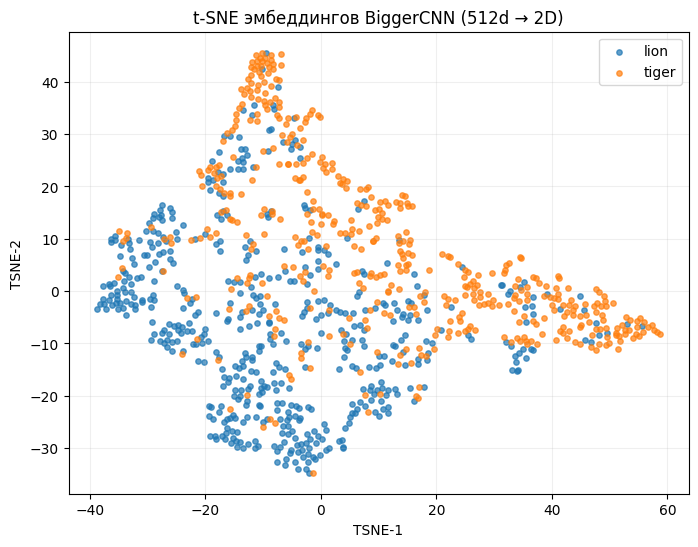

In [40]:
#t-SNE и визуализация
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

max_points = 1000
if embs.shape[0] > max_points:
    idx = np.random.choice(embs.shape[0], max_points, replace=False)
    embs_subset = embs[idx]
    labels_subset = labels[idx]
else:
    embs_subset = embs
    labels_subset = labels

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

embs_2d = tsne.fit_transform(embs_subset)

plt.figure(figsize=(8, 6))
for cls, color, name in [(0, "tab:orange", "lion"), (1, "tab:blue", "tiger")]:
    mask = labels_subset == cls
    plt.scatter(embs_2d[mask, 0], embs_2d[mask, 1], s=15, alpha=0.7, label=name)

plt.legend()
plt.title("t-SNE эмбеддингов BiggerCNN (512d → 2D)")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.grid(True, alpha=0.2)
plt.show()

In [42]:
#ResNet18 и создание модели
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
import torch.optim as optim

resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

for param in resnet.parameters():
    param.requires_grad = False

in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2),
)

resnet = resnet.to(device)

criterion_tl = nn.CrossEntropyLoss()
optimizer_tl = optim.Adam(resnet.fc.parameters(), lr=1e-3)

from torch.utils.tensorboard import SummaryWriter
writer_tl = SummaryWriter(log_dir="runs/resnet18_bigcats")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/viktoriabalakireva/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


In [43]:
import time
import logging
import torch

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger(__name__)

NUM_EPOCHS_TL = 10

best_val_acc_tl = 0.0
best_resnet_path = "best_resnet18_bigcats.pth"

start_time = time.time()

for epoch in range(1, NUM_EPOCHS_TL + 1):
    train_loss, train_acc = train_one_epoch(resnet, train_loader, criterion_tl, optimizer_tl, device)
    val_loss, val_acc     = evaluate(resnet, val_loader, criterion_tl, device)

    logger.info(
        f"[ResNet] Epoch {epoch:02d}/{NUM_EPOCHS_TL} | "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}"
    )

    writer_tl.add_scalar("Loss/train", train_loss, epoch)
    writer_tl.add_scalar("Loss/val",   val_loss,   epoch)
    writer_tl.add_scalar("Accuracy/train", train_acc, epoch)
    writer_tl.add_scalar("Accuracy/val",   val_acc,   epoch)

    if val_acc > best_val_acc_tl:
        best_val_acc_tl = val_acc
        torch.save(resnet.state_dict(), best_resnet_path)
        logger.info(f"→ New best ResNet model saved (val_acc={best_val_acc_tl:.4f})")

end_time = time.time()
tl_training_time = end_time - start_time
writer_tl.close()

logger.info(f"Обучение ResNet18 заняло {tl_training_time:.1f} секунд")

/Users/viktoriabalakireva/PycharmProjects/PythonProject7/.venv/lib/python3.13/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (96000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[ResNet] Epoch 01/10 | train_loss=0.3624 val_loss=0.2126 | train_acc=0.8240 val_acc=0.9160
  -> New best ResNet model saved (val_acc=0.9160)
[ResNet] Epoch 02/10 | train_loss=0.2233 val_loss=0.2715 | train_acc=0.9106 val_acc=0.8866
[ResNet] Epoch 03/10 | train_loss=0.2247 val_loss=0.1196 | train_acc=0.9106 val_acc=0.9496
  -> New best ResNet model saved (val_acc=0.9496)
[ResNet] Epoch 04/10 | train_loss=0.1496 val_loss=0.1180 | train_acc=0.9395 val_acc=0.9454
[ResNet] Epoch 05/10 | train_loss=0.1635 val_loss=0.1313 | train_acc=0.9323 val_acc=0.9412
[ResNet] Epoch 06/10 | train_loss=0.1583 val_loss=0.1234 | train_acc=0.9332 val_acc=0.9580
  -> New best ResNet model saved (val_acc=0.9580)
[ResNet] Epoch 07/10 | train_loss=0.1819 val_loss=0.1947 | train_acc=0.9251 val_acc=0.9160
[ResNet] Epoch 08/10 | train_loss=0.1512 val_loss=0.1529 | train_acc=0.9404 val_acc=0.9370
[ResNet] Epoch 09/10 | train_loss=0.1306 val_loss=0.1130 | train_acc=0.9486 val_acc=0.9538
[ResNet] Epoch 10/10 | train_lo

In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in best_resnet.parameters():
    param.requires_grad = False

in_features = best_resnet.fc.in_features
best_resnet.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2),
)
best_resnet = best_resnet.to(device)

best_resnet.load_state_dict(torch.load(best_resnet_path, map_location=device))
best_resnet.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_resnet(images)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

test_acc_tl = accuracy_score(all_labels, all_preds)
print("Test accuracy (ResNet18):", test_acc_tl)

print("\nClassification report (ResNet18):")
print(classification_report(all_labels, all_preds, target_names=["lion", "tiger"]))

print("Confusion matrix (ResNet18):")
print(confusion_matrix(all_labels, all_preds))

/Users/viktoriabalakireva/PycharmProjects/PythonProject7/.venv/lib/python3.13/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Test accuracy (ResNet18 TL): 0.9201680672268907

Classification report (ResNet18):
              precision    recall  f1-score   support

        lion       0.97      0.89      0.92       131
       tiger       0.87      0.96      0.92       107

    accuracy                           0.92       238
   macro avg       0.92      0.92      0.92       238
weighted avg       0.92      0.92      0.92       238

Confusion matrix (ResNet18):
[[116  15]
 [  4 103]]


In [49]:
#6 подводм итоги, сравниваем затраченное время на обучения обеих моделей и сравниваем метрики
import pandas as pd

results = {
    "Model": ["BiggerCNN", "ResNet18"],
    "Test Accuracy": [test_acc, test_acc_tl],
    "Training Time": [cnn_training_time, tl_training_time],
}

df_results = pd.DataFrame(results)
df_results

,Model,Test Accuracy,Training Time (sec)
0,BiggerCNN (from scratch),0.806723,2371.942167
1,ResNet18 (transfer learning),0.920168,829.257732
